In [2]:
import pandas as pd

races = pd.read_csv('../data/raw/races.csv')
results = pd.read_csv('../data/raw/results.csv')
drivers = pd.read_csv('../data/raw/drivers.csv')
constructors = pd.read_csv('../data/raw/constructors.csv')
sprint_results = pd.read_csv('../data/raw/sprint_results.csv')

In [4]:
def get_season_points_progression(year, races, results, sprint_results, drivers, top_n=5):
    season_races = races[races['year'] == year].sort_values('round')
    season_results = results[results['raceId'].isin(season_races['raceId'])].copy()
    season_sprint = sprint_results[sprint_results['raceId'].isin(season_races['raceId'])].copy()

    combined_results = pd.concat([
        season_results[['raceId', 'driverId', 'points']],
        season_sprint[['raceId', 'driverId', 'points']]
    ])

    combined_results = (
        combined_results
        .groupby(['raceId', 'driverId'])['points']
        .sum()
        .reset_index()
    )

    combined_results = combined_results.merge(
        season_races[['raceId', 'round']],
        on='raceId'
    )

    combined_results = combined_results.sort_values(['driverId', 'round'])
    combined_results['cumulative_points'] = (
        combined_results.groupby('driverId')['points'].cumsum()
    )

    final_totals = (
        combined_results.groupby('driverId')['points'].sum().sort_values(ascending=False)
    )
    top_drivers = final_totals.head(top_n).index

    result = combined_results[combined_results['driverId'].isin(top_drivers)]
    result = result.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')

    return result

In [6]:
progression_2021 = get_season_points_progression(2021, races, results, sprint_results, drivers, top_n=2)
progression_2021.head(20)

,raceId,driverId,points,round,cumulative_points,forename,surname
0,1052,1,25.0,1,25.0,Lewis,Hamilton
1,1053,1,19.0,2,44.0,Lewis,Hamilton
2,1054,1,25.0,3,69.0,Lewis,Hamilton
3,1055,1,25.0,4,94.0,Lewis,Hamilton
4,1056,1,7.0,5,101.0,Lewis,Hamilton
5,1057,1,0.0,6,101.0,Lewis,Hamilton
6,1059,1,18.0,7,119.0,Lewis,Hamilton
7,1058,1,19.0,8,138.0,Lewis,Hamilton
8,1060,1,12.0,9,150.0,Lewis,Hamilton
9,1061,1,27.0,10,177.0,Lewis,Hamilton


In [8]:
import matplotlib.pyplot as plt

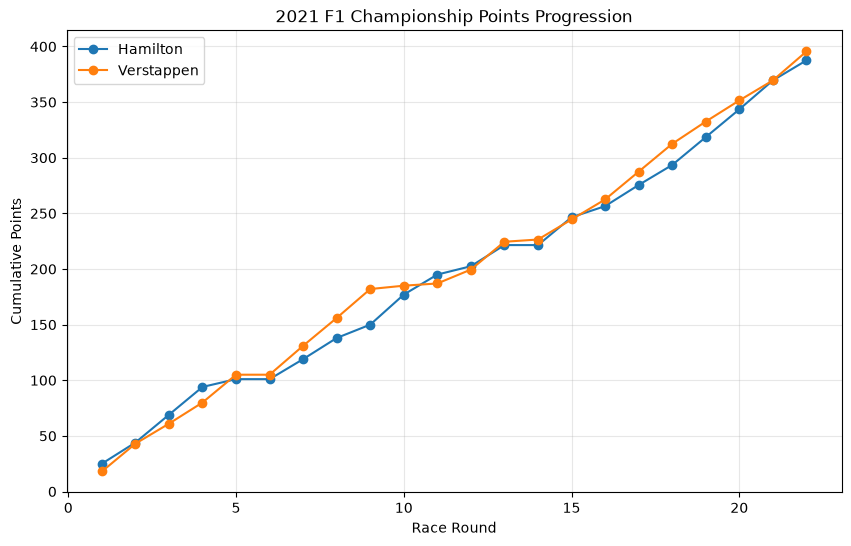

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

for driver_id, driver_data in progression_2021.groupby('driverId'):
    name = driver_data['surname'].iloc[0]
    ax.plot(driver_data['round'], driver_data['cumulative_points'], marker='o', label=name)

ax.set_xlabel('Race Round')
ax.set_ylabel('Cumulative Points')
ax.set_title('2021 F1 Championship Points Progression')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('../data/2021_points_progression.png', dpi=150, bbox_inches='tight')
plt.show()

## 2021 Championship Points Progression

This chart shows cumulative points for the top 5 drivers of the 2021 season, race by race. The 2021 title fight between Hamilton and Verstappen was one of the closest in F1 history, decided only on the final lap of the final race — visible here as the two lines stay nearly identical for most of the season before separating near the end.